In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df['CustomerId'].duplicated().sum()

np.int64(0)

In [ ]:
df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


In [ ]:
df = df.drop(columns=['CustomerId', 'Surname'])
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print(df['Year'].unique())
df = df.drop(columns=['Year'])

[2025]


In [ ]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
df['Balance_to_Salary'] = df['Balance'] / df['EstimatedSalary']
df['Engagement_product'] = df['IsActiveMember'] * df['NumOfProducts']
df['Age_tenure'] = df['Age'] * df['Tenure']
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,Balance_to_Salary,Engagement_product,Age_tenure
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,1,84
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744677,1,41
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401375,0,336
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,0,39
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587055,1,86


In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print(X.shape)
print(y.shape)

(10000, 14)
(10000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(8000, 14) (2000, 14)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = log_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.712


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1593
           1       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)  # tree models don't need scaled data

y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      1593
           1       0.44      0.77      0.56       407

    accuracy                           0.76      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.76      0.78      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.70      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.83      0.83      2000



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [ ]:
from sklearn.metrics import roc_auc_score

for name, model, X_te in [
    ("Logistic Regression", log_model, X_test_scaled),
    ("Decision Tree", dt_model, X_test),
    ("Random Forest", rf_model, X_test),
    ("Gradient Boosting", gb_model, X_test),
]:
    proba = model.predict_proba(X_te)[:, 1]
    print(f"{name}: ROC-AUC = {roc_auc_score(y_test, proba):.4f}")

Logistic Regression: ROC-AUC = 0.7764
Decision Tree: ROC-AUC = 0.8262
Random Forest: ROC-AUC = 0.8668
Gradient Boosting: ROC-AUC = 0.8696


In [ ]:
results = []
for name, model, X_te in [
    ("Logistic Regression", log_model, X_test_scaled),
    ("Decision Tree", dt_model, X_test),
    ("Random Forest", rf_model, X_test),
    ("Gradient Boosting", gb_model, X_test),
]:
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall        F1   ROC-AUC
0  Logistic Regression   0.386272  0.705160  0.499130  0.776390
1        Decision Tree   0.443343  0.769042  0.562444  0.826239
2        Random Forest   0.556641  0.700246  0.620239  0.866807
3    Gradient Boosting   0.791339  0.493857  0.608169  0.869601


In [ ]:
best_row = results_df.sort_values('F1', ascending=False).iloc[0]
best_model_name = best_row['Model']
print("Best model:", best_model_name)
print(results_df.sort_values('F1', ascending=False))

Best model: Random Forest
                 Model  Precision    Recall        F1   ROC-AUC
2        Random Forest   0.556641  0.700246  0.620239  0.866807
3    Gradient Boosting   0.791339  0.493857  0.608169  0.869601
1        Decision Tree   0.443343  0.769042  0.562444  0.826239
0  Logistic Regression   0.386272  0.705160  0.499130  0.776390


In [ ]:
models_dict = {
    "Logistic Regression": (log_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test),
}

best_model, X_test_best = models_dict[best_model_name]

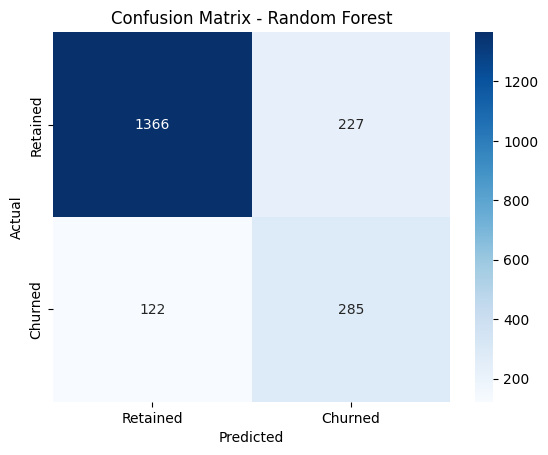

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds_best = best_model.predict(X_test_best)
cm = confusion_matrix(y_test, preds_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

Age                   0.318706
NumOfProducts         0.191826
Engagement_product    0.094162
Balance               0.065730
Age_tenure            0.058072
Geography_Germany     0.055266
Balance_to_Salary     0.049219
IsActiveMember        0.038833
EstimatedSalary       0.038390
CreditScore           0.037183
dtype: float64


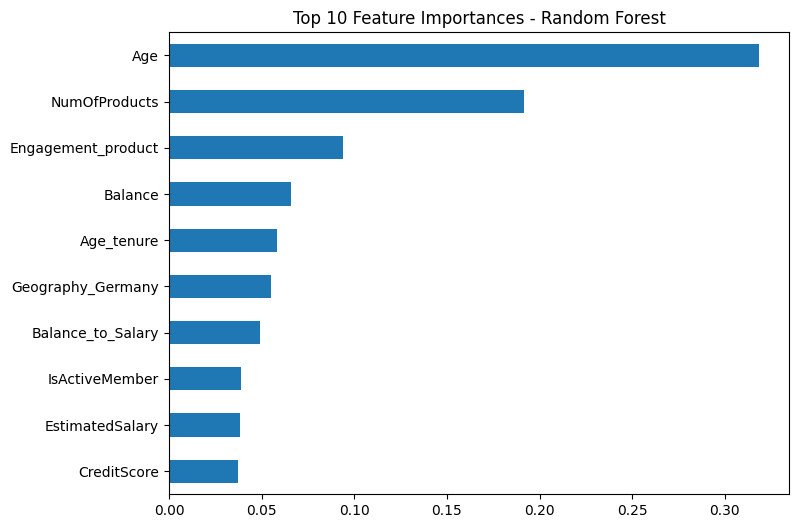

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

importances.head(10).sort_values().plot(kind='barh', figsize=(8,6))
plt.title(f'Top 10 Feature Importances - {best_model_name}')
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Saved!")

Saved!


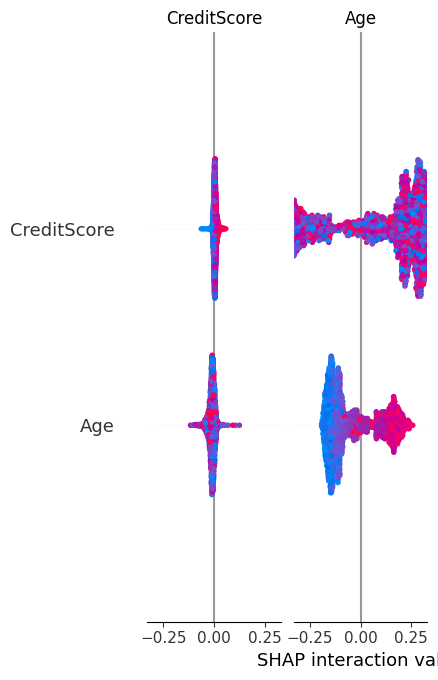

In [ ]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_best)

# For Random Forest, shap_values may be a list [class_0, class_1] - take class 1 (churn)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_best)

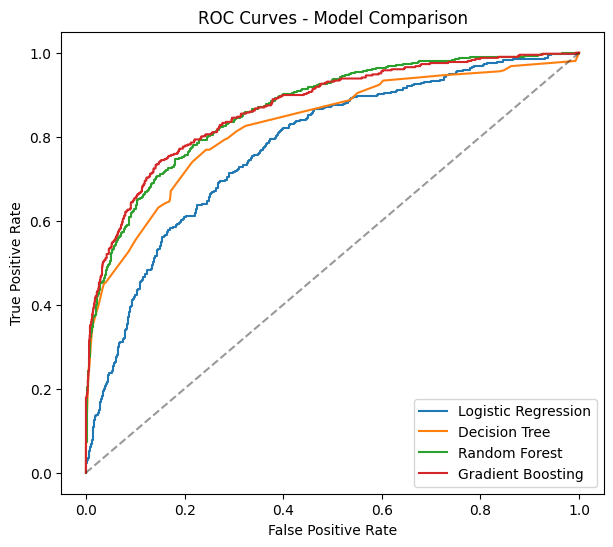

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))
for name, model, X_te in [
    ("Logistic Regression", log_model, X_test_scaled),
    ("Decision Tree", dt_model, X_test),
    ("Random Forest", rf_model, X_test),
    ("Gradient Boosting", gb_model, X_test),
]:
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()

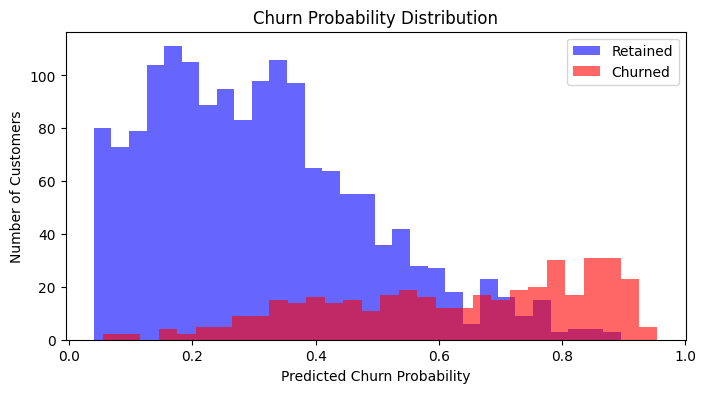

In [ ]:
all_proba = best_model.predict_proba(X_test_best)[:, 1]

plt.figure(figsize=(8,4))
plt.hist(all_proba[y_test==0], bins=30, alpha=0.6, label='Retained', color='blue')
plt.hist(all_proba[y_test==1], bins=30, alpha=0.6, label='Churned', color='red')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Number of Customers')
plt.legend()
plt.title('Churn Probability Distribution')
plt.show()

In [ ]:
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved!")

Scaler saved!


In [ ]:
from google.colab import files
files.download('best_model.pkl')
files.download('feature_columns.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>